In [1]:
## This script is to plot RAOB of Flagstaff for the 15 August case study 
## Created by C. Bayu Risanto, S.J. (5 September 2025)
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import metpy.calc as mpcalc
from metpy.cbook import get_test_data
from metpy.plots import add_metpy_logo, Hodograph, SkewT
from metpy.units import units
import xarray as xr
import dateutil.parser
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mplotcolors
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from copy import copy
import shapely.geometry as sgeom
from datetime import date, datetime, timedelta
# create ncfile opener
def read_mrms(link,ncfile):
    fname = link + ncfile
    ds = xr.open_dataset(fname)
    pcp = ds.PRECIP[:,:,:]
    return pcp
def read_latlon(link,ncfile):
    fname = link + ncfile
    ds = xr.open_dataset(fname)
    lat = ds.lat_0[:]
    lon = ds.lon_0[:]
    return lat,lon
def read_merg(link,ncfile):
    fname = link+ncfile
    ds = xr.open_dataset(fname)
    Tb = ds.to_array('Tb',None)
    tb = ds.Tb[0,:,:]
    return tb
def read_mrlon(link,ncfile):
    fname = link+ncfile
    ds = xr.open_dataset(fname)
    lon = ds.lon[:]
    lat = ds.lat[:]
    return lat,lon

In [2]:
## read data
path = '/secchi/bayu/DATA/ARIZONA_PRO/OBS/RAOB/FGZ/'
tfi12 = 'FGZ_2021081512.dat'
col_names12 = ['pressure', 'height', 'temperature', 'dewpoint', 'direction', 'speed']
df12 = pd.read_fwf(path+tfi12,
                 skiprows=5, usecols=[0, 1, 2, 3, 6, 7], names=col_names12)

# Drop any rows with all NaN values for T, Td, winds
df12 = df12.dropna(subset=('temperature', 'dewpoint', 'direction', 'speed'),
               how='all').reset_index(drop=True)

tfi00 = 'FGZ_2021081600.dat'
col_names00 = ['pressure', 'height', 'temperature', 'dewpoint', 'direction', 'speed']
df00 = pd.read_fwf(path+tfi00,
                 skiprows=5, usecols=[0, 1, 2, 3, 6, 7], names=col_names00)

# Drop any rows with all NaN values for T, Td, winds
df00 = df00.dropna(subset=('temperature', 'dewpoint', 'direction', 'speed'),
               how='all').reset_index(drop=True)

In [3]:
## pull the data out
p12 = df12['pressure'].values * units.hPa
z12 = df12['height'].values * units.m
T12 = df12['temperature'].values * units.degC
Td12 = df12['dewpoint'].values * units.degC
wind_speed12 = df12['speed'].values * units.knots
wind_dir12 = df12['direction'].values * units.degrees
u12, v12 = mpcalc.wind_components(wind_speed12, wind_dir12)
pw12 = mpcalc.precipitable_water(p12, Td12)

p00 = df00['pressure'].values * units.hPa
z00 = df00['height'].values * units.m
T00 = df00['temperature'].values * units.degC
Td00 = df00['dewpoint'].values * units.degC
wind_speed00 = df00['speed'].values * units.knots
wind_dir00 = df00['direction'].values * units.degrees
u00, v00 = mpcalc.wind_components(wind_speed00, wind_dir00)
pw00 = mpcalc.precipitable_water(p00, Td00)

In [4]:
print(pw12)
print(pw00)

16.29150351771736 millimeter
22.643563363940608 millimeter


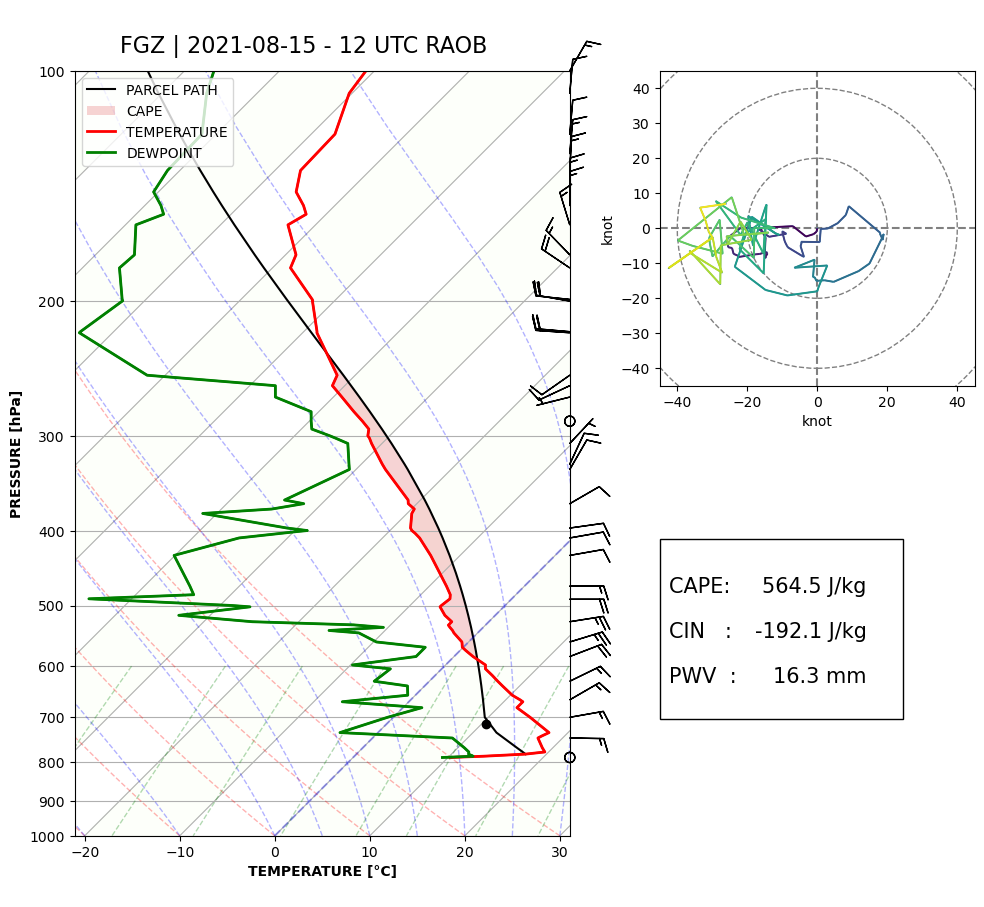

In [5]:
## PLOT
T = T12.copy()
p = p12.copy()
z = z12.copy()
Td = Td12.copy()
wind_speed = wind_speed12.copy()
wind_dir = wind_dir12.copy()
u = u12.copy()
v = v12.copy()
pwv = pw12.copy()

fig = plt.figure(figsize=(9, 9))
skew = SkewT(fig, rotation=45, rect=(0.1, 0.1, 0.55, 0.85))

# Plot the data using normal plotting functions, in this case using
skew.plot(p, T, 'r')
skew.plot(p, Td, 'g')
# the wind barbs for a cleaner output with increased readability.
interval = np.logspace(2, 3, 40) * units.hPa
idx = mpcalc.resample_nn_1d(p, interval)
skew.plot_barbs(pressure=p[idx], u=u[idx], v=v[idx])

# Calculate full parcel profile and add to plot as black line
prof = mpcalc.parcel_profile(p, T[0], Td[0]).to('degC')
# Shade areas of CAPE 
p_new = p[2:]
T_new = T[2:]
Td_new = Td[2:]
prof_new = mpcalc.parcel_profile(p_new, T[2], Td[2]).to('degC')
skew.plot(p_new, prof_new, 'k', linewidth=1.5, label='PARCEL PATH')
skew.shade_cape(p_new, T_new, prof_new, alpha=0.2, label='CAPE')
##skew.plot(p, prof, 'k', linewidth=1.5, label='SB PARCEL PATH')
##skew.shade_cape(p, T, prof, alpha=0.2, label='CAPE')

# Calculate LCL height and plot as a black dot. Because `p`'s first value is
lcl_pressure, lcl_temperature = mpcalc.lcl(p[2], T[2], Td[2])
skew.plot(lcl_pressure, lcl_temperature, 'ko', markerfacecolor='black')

# Estimate CAPE CIN
cape,cin = mpcalc.cape_cin(p_new,T_new,Td_new,prof_new)

# Change to adjust data limits and give it a semblance of what we want
skew.ax.set_adjustable('datalim')
skew.ax.set_ylim(1000, 100)
skew.ax.set_xlim(-20, 30)

# Set some better labels than the default to increase readability
skew.ax.set_xlabel(str.upper(f'Temperature [{T.units:~P}]'), weight='bold')
skew.ax.set_ylabel('PRESSURE [hPa]', weight='bold')

# Set the facecolor of the skew-t object and the figure to white
fig.set_facecolor('#ffffff')
skew.ax.set_facecolor('#ffffff')

# Here we can use some basic math and Python functionality to make a cool
# shaded isotherm pattern.
x1 = np.linspace(-100, 40, 8)
x2 = np.linspace(-90, 50, 8)
y = [1100, 50]
for i in range(0, 8):
    skew.shade_area(y=y, x1=x1[i], x2=x2[i], color='greenyellow', alpha=0.02, zorder=0)
    
# Add the relevant special lines native to the Skew-T Log-P diagram &
skew.ax.axvline(0 * units.degC, linestyle='--', color='blue', alpha=0.3)
skew.plot_dry_adiabats(lw=1, alpha=0.3)
skew.plot_moist_adiabats(lw=1, alpha=0.3)
skew.plot_mixing_lines(lw=1, alpha=0.3)

# STEP 2: PLOT DATA ON THE SKEW-T. TAKE A COUPLE EXTRA STEPS TO
# We will also add the 'label' keyword argument for our legend.
skew.plot(p, T, 'r', lw=2, label='TEMPERATURE')
skew.plot(p, Td, 'g', lw=2, label='DEWPOINT')

# Create a hodograph
ax = plt.axes((0.75, 0.6, 0.35, 0.35))
h = Hodograph(ax, component_range=45.)
h.add_grid(increment=20)
h.plot(u, v, linewidth=1)
h.plot_colormapped(u, v, c=z, linewidth=1.4,)

# Add legends to the skew and hodo
skewleg = skew.ax.legend(loc='upper left')

# STEP 4: ADD A FEW EXTRA ELEMENTS TO REALLY MAKE A NEAT PLOT
# First we want to actually add values of data to the plot for easy viewing
# To do this, let's first add a simple rectangle using Matplotlib's 'patches'
# functionality to add some simple layout for plotting calculated parameters
#                                  xloc   yloc   xsize  ysize
fig.patches.extend([plt.Rectangle((0.75, 0.23), 0.27, 0.20,
                                  edgecolor='black', facecolor='white',
                                  linewidth=1, alpha=1, transform=fig.transFigure,
                                  figure=fig)])

# There is a lot we can do with this data operationally, so let's plot some of
# these values right on the plot, in the box we made
# First lets plot some thermodynamic parameters
plt.figtext(0.76, 0.37, 'CAPE: ', fontsize=15,
            color='black', ha='left')
plt.figtext(0.98, 0.37, f'{cape:.1f~P}',
            fontsize=15, color='k', ha='right')
plt.figtext(0.76, 0.32, 'CIN   : ', fontsize=15,
            color='black', ha='left')
plt.figtext(0.98, 0.32, f'{cin:.1f~P}',
            fontsize=15, color='k', ha='right')
plt.figtext(0.76, 0.27, 'PWV  : ', fontsize=15,
            color='black', ha='left')
plt.figtext(0.98, 0.27, f'{pwv:.1f~P}',
            fontsize=15, color='k', ha='right')

plt.figtext(0.15, 0.97, 'FGZ | 2021-08-15 - 12 UTC RAOB',
            fontsize=16, ha='left')

## SAVE
dir_out = '/secchi/bayu/PLOTS/ARIZONA_PRO/RAOB/'
plotfile  = 'RAOB-'+tfi12[0:14]+'_event.png'
sf = fig.savefig(dir_out+plotfile, dpi=300, bbox_inches='tight')

plt.show()
plt.close()

In [6]:
print(cape)

564.5066441261001 joule / kilogram


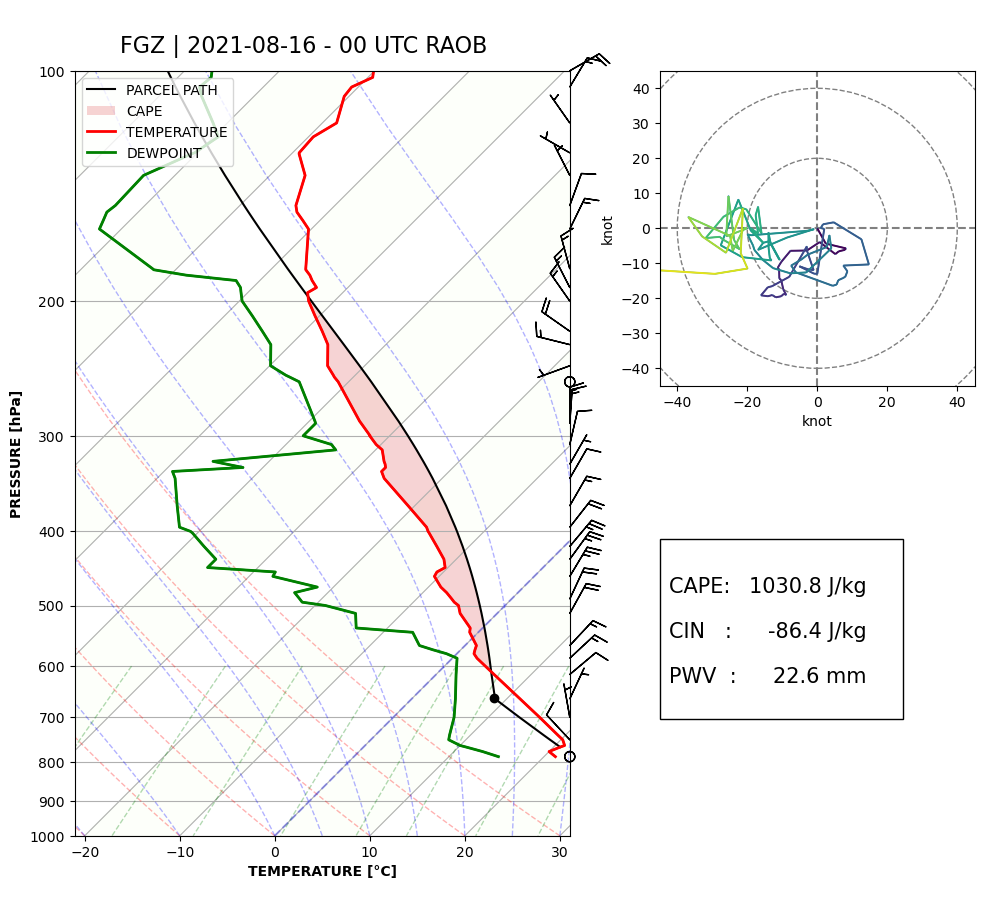

In [7]:
## PLOT
T = T00.copy()
p = p00.copy()
z = z00.copy()
Td = Td00.copy()
wind_speed = wind_speed00.copy()
wind_dir = wind_dir00.copy()
u = u00.copy()
v = v00.copy()
pwv = pw00.copy()

fig = plt.figure(figsize=(9, 9))
skew = SkewT(fig, rotation=45, rect=(0.1, 0.1, 0.55, 0.85))

# Plot the data using normal plotting functions, in this case using
skew.plot(p, T, 'r')
skew.plot(p, Td, 'g')
# the wind barbs for a cleaner output with increased readability.
interval = np.logspace(2, 3, 40) * units.hPa
idx = mpcalc.resample_nn_1d(p, interval)
skew.plot_barbs(pressure=p[idx], u=u[idx], v=v[idx])

# Calculate full parcel profile and add to plot as black line
prof = mpcalc.parcel_profile(p, T[0], Td[0]).to('degC')
# Shade areas of CAPE 
p_new = p[2:]
T_new = T[2:]
Td_new = Td[2:]
prof_new = mpcalc.parcel_profile(p_new, T[2], Td[2]).to('degC')
skew.plot(p_new, prof_new, 'k', linewidth=1.5, label='PARCEL PATH')
skew.shade_cape(p_new, T_new, prof_new, alpha=0.2, label='CAPE')
##skew.plot(p, prof, 'k', linewidth=1.5, label='SB PARCEL PATH')
##skew.shade_cape(p, T, prof, alpha=0.2, label='CAPE')

# Calculate LCL height and plot as a black dot. Because `p`'s first value is
lcl_pressure, lcl_temperature = mpcalc.lcl(p[2], T[2], Td[2])
skew.plot(lcl_pressure, lcl_temperature, 'ko', markerfacecolor='black')

# Estimate CAPE CIN
cape,cin = mpcalc.cape_cin(p_new,T_new,Td_new,prof_new)

# Change to adjust data limits and give it a semblance of what we want
skew.ax.set_adjustable('datalim')
skew.ax.set_ylim(1000, 100)
skew.ax.set_xlim(-20, 30)

# Set some better labels than the default to increase readability
skew.ax.set_xlabel(str.upper(f'Temperature [{T.units:~P}]'), weight='bold')
skew.ax.set_ylabel('PRESSURE [hPa]', weight='bold')

# Set the facecolor of the skew-t object and the figure to white
fig.set_facecolor('#ffffff')
skew.ax.set_facecolor('#ffffff')

# Here we can use some basic math and Python functionality to make a cool
# shaded isotherm pattern.
x1 = np.linspace(-100, 40, 8)
x2 = np.linspace(-90, 50, 8)
y = [1100, 50]
for i in range(0, 8):
    skew.shade_area(y=y, x1=x1[i], x2=x2[i], color='greenyellow', alpha=0.02, zorder=0)
    
# Add the relevant special lines native to the Skew-T Log-P diagram &
skew.ax.axvline(0 * units.degC, linestyle='--', color='blue', alpha=0.3)
skew.plot_dry_adiabats(lw=1, alpha=0.3)
skew.plot_moist_adiabats(lw=1, alpha=0.3)
skew.plot_mixing_lines(lw=1, alpha=0.3)

# STEP 2: PLOT DATA ON THE SKEW-T. TAKE A COUPLE EXTRA STEPS TO
# We will also add the 'label' keyword argument for our legend.
skew.plot(p, T, 'r', lw=2, label='TEMPERATURE')
skew.plot(p, Td, 'g', lw=2, label='DEWPOINT')

# Create a hodograph
ax = plt.axes((0.75, 0.6, 0.35, 0.35))
h = Hodograph(ax, component_range=45.)
h.add_grid(increment=20)
h.plot(u, v, linewidth=1)
h.plot_colormapped(u, v, c=z, linewidth=1.4,)

# Add legends to the skew and hodo
skewleg = skew.ax.legend(loc='upper left')

# STEP 4: ADD A FEW EXTRA ELEMENTS TO REALLY MAKE A NEAT PLOT
# First we want to actually add values of data to the plot for easy viewing
# To do this, let's first add a simple rectangle using Matplotlib's 'patches'
# functionality to add some simple layout for plotting calculated parameters
#                                  xloc   yloc   xsize  ysize
fig.patches.extend([plt.Rectangle((0.75, 0.23), 0.27, 0.20,
                                  edgecolor='black', facecolor='white',
                                  linewidth=1, alpha=1, transform=fig.transFigure,
                                  figure=fig)])

# There is a lot we can do with this data operationally, so let's plot some of
# these values right on the plot, in the box we made
# First lets plot some thermodynamic parameters
plt.figtext(0.76, 0.37, 'CAPE: ', fontsize=15,
            color='black', ha='left')
plt.figtext(0.98, 0.37, f'{cape:.1f~P}',
            fontsize=15, color='k', ha='right')
plt.figtext(0.76, 0.32, 'CIN   : ', fontsize=15,
            color='black', ha='left')
plt.figtext(0.98, 0.32, f'{cin:.1f~P}',
            fontsize=15, color='k', ha='right')
plt.figtext(0.76, 0.27, 'PWV  : ', fontsize=15,
            color='black', ha='left')
plt.figtext(0.98, 0.27, f'{pwv:.1f~P}',
            fontsize=15, color='k', ha='right')

plt.figtext(0.15, 0.97, 'FGZ | 2021-08-16 - 00 UTC RAOB',
            fontsize=16, ha='left')

## SAVE
dir_out = '/secchi/bayu/PLOTS/ARIZONA_PRO/RAOB/'
plotfile  = 'RAOB-'+tfi00[0:14]+'_event.png'
sf = fig.savefig(dir_out+plotfile, dpi=300, bbox_inches='tight')

plt.show()
plt.close()